# Import setting

In [1]:
import os

print(os.getcwd())
if not os.getcwd().endswith("app"):
    os.chdir("../app")
    print(os.getcwd())

%load_ext autoreload
%autoreload 2

from src.config import Configuration

CONFIG = Configuration(
    batch_size=8, # que sino no caben los 3
)

/home/turbotowerlnx/Documents/Master/VPC/VPC-Labs/notebooks
/home/turbotowerlnx/Documents/Master/VPC/VPC-Labs/app
________________________________________________________________________________________________________________________________
                                                         CONFIGURATION                                                          

Experiment description: Base experiment description
Experiment name: base_name
Model type: small
seed: 42
batch_size: 8
epochs: 100
dropout_rate: 0.5
label_smoothing: 0.1
learning_rate: 0.01
weight_decay: 0.0001
eta_min: 1e-06
momentum: 0.9
lr_reduce_factor: 0.5
lr_patience: 3
patience: 10



# Load data

In [2]:
from src.data import load_gender_data

train_loader, test_loader = load_gender_data(CONFIG, use_transforms=False)

In [3]:
import numpy as np

x_train = np.load(CONFIG.gender_x_train)
x_test = np.load(CONFIG.gender_x_test)

y_train = np.load(CONFIG.gender_y_train)
y_test = np.load(CONFIG.gender_y_test)


# Load models

In [ ]:
import torch
from src.models import GenderModule


top_models = [
    # ("gender-seed=50-jitter-val_acc=0.9660.ckpt", None),
    # ("gender-seed=66-val_acc=0.9641.ckpt", None),
    # ("gender-seed=42-mask-random-val_acc=0.9709.ckpt", None),
    # ("gender-seed=42-custom-val_acc=0.9645.ckpt", None), 
    # ("gender-seed=50-jitter-val_acc=0.9660.ckpt", None),
    # ("gender-large-dr-0.25-val_acc=0.9687.ckpt", torch.tensor([0.4, 0.6])),
    ("gender-seed=42-mask-random-val_acc=0.9709.ckpt", None), 
    ("gender-large-wb-val_acc=0.9649.ckpt", torch.tensor([0.4,0.6])),
    ("gender-small-epoch=82-val_acc=0.9675.ckpt", None)
]

loaded_models = []
for ckpt, weights in top_models:
    if 'small' in ckpt:
        CONFIG.model_type = 'small'
    else: 
        CONFIG.model_type = 'large'

    print(f"Loading model from checkpoint: {ckpt} with model type: {CONFIG.model_type}")

    lightning_model = GenderModule.load_from_checkpoint(
        os.path.join(CONFIG.gender_models, 'bests', ckpt),
        CONFIG=CONFIG,
        map_location=CONFIG.device,
        weights=weights
    )
    lightning_model.eval()
    lightning_model.to(CONFIG.device)
    loaded_models.append(lightning_model)

print(f"Loaded {len(loaded_models)} models")

Loading model from checkpoint: gender-seed=42-mask-random-val_acc=0.9709.ckpt with model type: large
Loading model from checkpoint: gender-small-epoch=82-val_acc=0.9675.ckpt with model type: small
Loaded 2 models


In [10]:
@torch.no_grad()
def predict_probs_tta(lightning_model, images):
    # Batch-wise TTA: average probs from original and horizontally flipped images.
    logits = lightning_model(images)
    probs = torch.softmax(logits, dim=1)

    images_flipped = torch.flip(images, dims=[3])  # flip width axis (N, C, H, W)
    logits_flipped = lightning_model(images_flipped)
    probs_flipped = torch.softmax(logits_flipped, dim=1)

    return (probs + probs_flipped) / 2.0


@torch.no_grad()
def collect_binary_outputs(lightning_model, data_loader, device):
    labels_all = []
    pos_probs_all = []

    for images, labels in data_loader:
        images = images.to(device)
        probs = predict_probs_tta(lightning_model, images)
        pos_probs = probs[:, 1]  # probability of class 1

        labels_all.append(labels.cpu().long())
        pos_probs_all.append(pos_probs.cpu())

    return torch.cat(labels_all), torch.cat(pos_probs_all)


def find_best_threshold(labels, pos_probs, num_thresholds=1001):
    thresholds = torch.linspace(0.0, 1.0, num_thresholds)
    preds = (pos_probs.unsqueeze(0) >= thresholds.unsqueeze(1)).long()
    accs = (preds == labels.unsqueeze(0)).float().mean(dim=1)

    best_idx = torch.argmax(accs)
    return thresholds[best_idx].item(), accs[best_idx].item()


@torch.no_grad()
def evaluate_ensemble(models, data_loader, device):
    correct = 0
    total = 0
    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        probs_sum = None
        for m in models:
            probs = predict_probs_tta(m, images)
            probs_sum = probs if probs_sum is None else probs_sum + probs

        probs_avg = probs_sum / len(models)
        ensemble_preds = torch.argmax(probs_avg, dim=1)
        correct += (ensemble_preds == labels).sum().item()
        total += labels.numel()

    return correct / total if total > 0 else 0.0


# Individual model threshold search (with TTA)
individual_results = []
for i, m in enumerate(loaded_models, start=1):
    labels_all, pos_probs_all = collect_binary_outputs(m, test_loader, CONFIG.device)
    best_threshold, best_acc = find_best_threshold(labels_all, pos_probs_all)
    individual_results.append({
        "model": i,
        "best_threshold": best_threshold,
        "best_acc": best_acc,
    })
    print(
        f"model_{i} best threshold (TTA): {best_threshold:.3f} | "
        f"accuracy: {best_acc:.4f}"
    )


# Soft-voting ensemble accuracy (with TTA, argmax)
ensemble_acc = evaluate_ensemble(loaded_models, test_loader, CONFIG.device)
print(f"ensemble accuracy (TTA): {ensemble_acc:.4f}")

model_1 best threshold (TTA): 0.520 | accuracy: 0.9724
ensemble accuracy (TTA): 0.9717


# Analysis mistakes

In [11]:
import torch
import matplotlib.pyplot as plt


def _to_display_image(img):
    # Convert CHW tensor to HWC and rescale for visualization.
    img = img.detach().cpu().permute(1, 2, 0)
    img_min = img.min()
    img_max = img.max()
    if (img_max - img_min) > 0:
        img = (img - img_min) / (img_max - img_min)
    return img


@torch.no_grad()
def collect_ensemble_misclassified(models, data_loader, device):
    wrong_images = []
    wrong_labels = []
    wrong_preds = []

    for images, labels in data_loader:
        images_device = images.to(device)
        labels_device = labels.to(device)

        probs_sum = None
        for m in models:
            probs = predict_probs_tta(m, images_device)
            probs_sum = probs if probs_sum is None else probs_sum + probs

        probs_avg = probs_sum / len(models)
        preds = torch.argmax(probs_avg, dim=1)
        wrong_mask = preds != labels_device

        if wrong_mask.any():
            wrong_mask_cpu = wrong_mask.cpu()
            wrong_images.append(images[wrong_mask_cpu].cpu())
            wrong_labels.append(labels[wrong_mask_cpu].cpu())
            wrong_preds.append(preds[wrong_mask].cpu())

    if len(wrong_images) == 0:
        return torch.empty(0), torch.empty(0, dtype=torch.long), torch.empty(0, dtype=torch.long)

    return torch.cat(wrong_images), torch.cat(wrong_labels), torch.cat(wrong_preds)


wrong_images, wrong_labels, wrong_preds = collect_ensemble_misclassified(
    loaded_models, test_loader, CONFIG.device
)

Total misclassified samples: 75


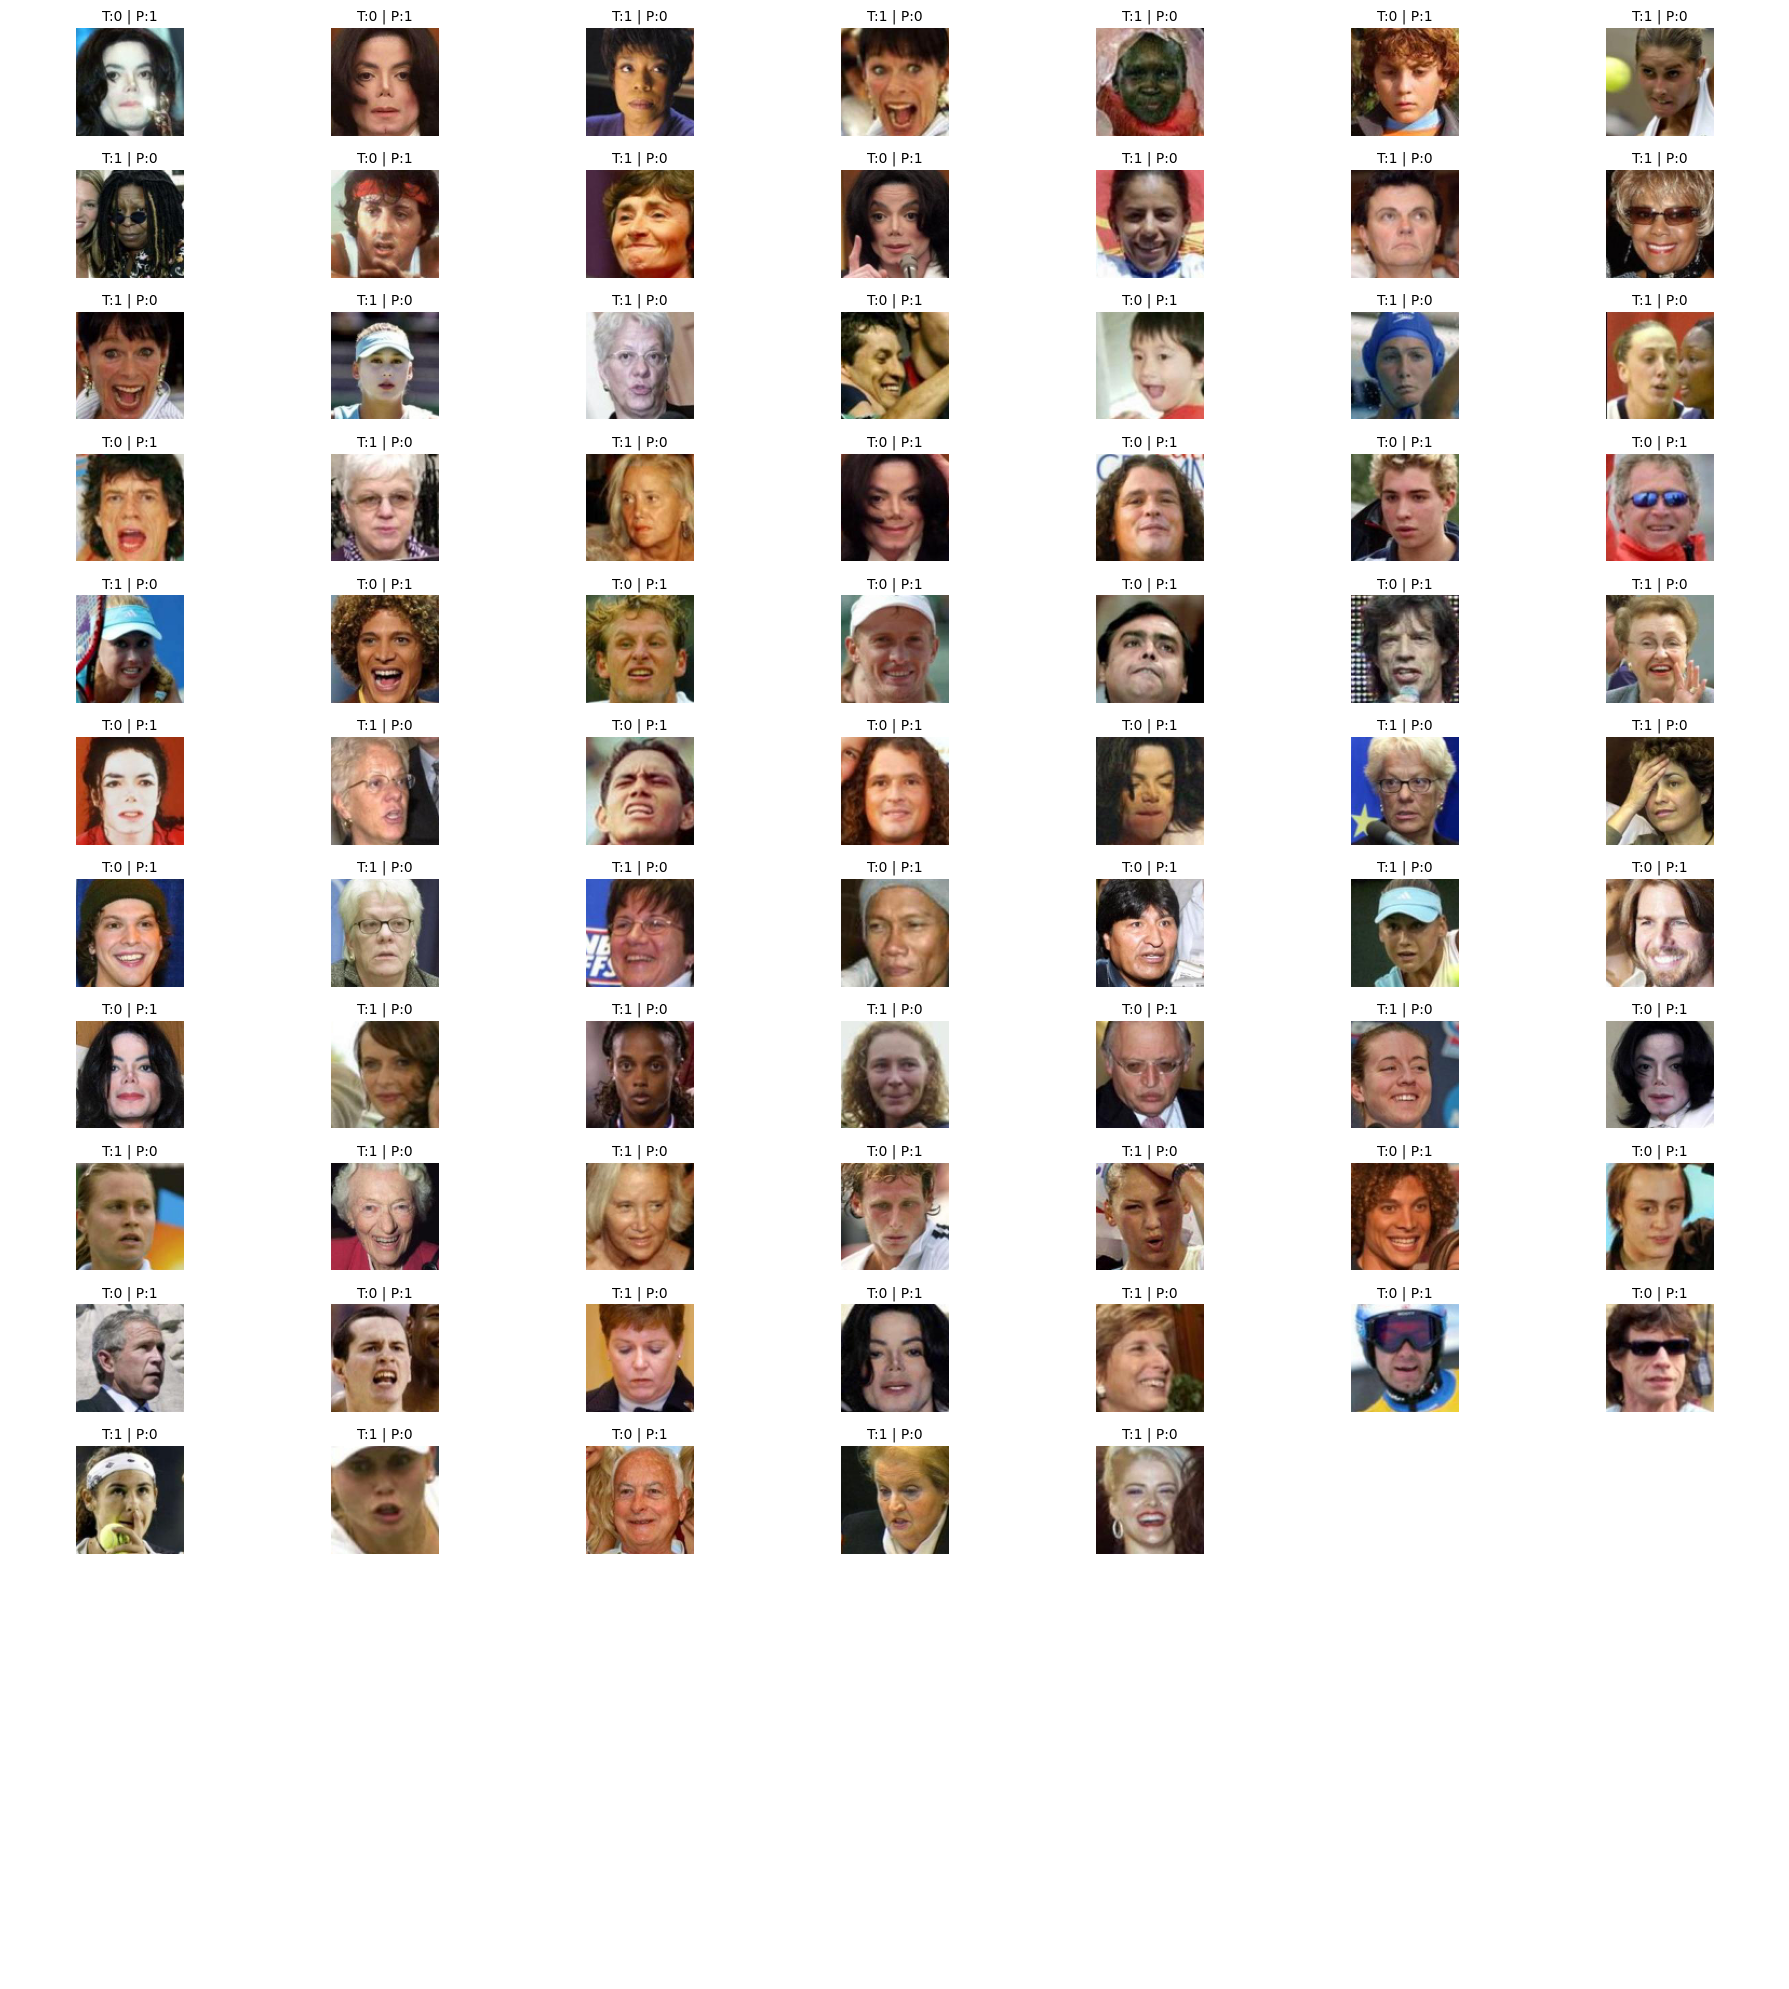

In [12]:

print(f"Total misclassified samples: {len(wrong_images)}")

n_rows, n_cols = 14, 7
n_show = min(n_rows * n_cols, len(wrong_images))

if n_show == 0:
    print("No misclassified samples found.")
else:
    idx = torch.randperm(len(wrong_images))[:n_show]
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 20))
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        if i < n_show:
            img = _to_display_image(wrong_images[idx[i]])
            true_label = int(wrong_labels[idx[i]].item())
            pred_label = int(wrong_preds[idx[i]].item())
            ax.imshow(img)
            ax.set_title(f"T:{true_label} | P:{pred_label}", fontsize=10)
            ax.axis("off")
        else:
            ax.axis("off")

    plt.tight_layout()
    plt.show()